In [2]:
import pandas as pd
import numpy as np

print("="*60)
print("MIMIC-III")
print("="*60)

admissions = pd.read_csv('mimic-iii/ADMISSIONS.csv')
diagnoses = pd.read_csv('mimic-iii/DIAGNOSES_ICD.csv')

print("Admissions shape:", admissions.shape)
print("Diagnoses shape:", diagnoses.shape)
print("\nAdmissions columns:", admissions.columns.tolist())
print("Diagnoses columns:", diagnoses.columns.tolist())

# 从admissions数据中计算每个病人的住院次数
patient_admission_counts = admissions.groupby('SUBJECT_ID')['HADM_ID'].nunique()

print(f"\nNumber of patients: {len(patient_admission_counts)}")
print(f"Average number of admissions per patient: {patient_admission_counts.mean():.2f}")
print(f"Maximum number of admissions per patient: {patient_admission_counts.max()}")
print(f"Minimum number of admissions per patient: {patient_admission_counts.min()}")

MIMIC-III
Admissions shape: (58976, 19)
Diagnoses shape: (651047, 5)

Admissions columns: ['ROW_ID', 'SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'DISCHTIME', 'DEATHTIME', 'ADMISSION_TYPE', 'ADMISSION_LOCATION', 'DISCHARGE_LOCATION', 'INSURANCE', 'LANGUAGE', 'RELIGION', 'MARITAL_STATUS', 'ETHNICITY', 'EDREGTIME', 'EDOUTTIME', 'DIAGNOSIS', 'HOSPITAL_EXPIRE_FLAG', 'HAS_CHARTEVENTS_DATA']
Diagnoses columns: ['ROW_ID', 'SUBJECT_ID', 'HADM_ID', 'SEQ_NUM', 'ICD9_CODE']

Number of patients: 46520
Average number of admissions per patient: 1.27
Maximum number of admissions per patient: 42
Minimum number of admissions per patient: 1


In [3]:
def preprocess_data(diagnoses, admissions):
    """Preprocess the MIMIC-III data"""
    
    diagnoses_clean = diagnoses.copy()
    diagnoses_clean = diagnoses_clean.dropna(subset=['SUBJECT_ID', 'HADM_ID', 'ICD9_CODE'])
    
    admissions_clean = admissions.copy()
    admissions_clean = admissions_clean.dropna(subset=['SUBJECT_ID', 'HADM_ID', 'ADMITTIME'])
    
    # time format conversion
    admissions_clean['ADMITTIME'] = pd.to_datetime(admissions_clean['ADMITTIME'])
    admissions_clean['DISCHTIME'] = pd.to_datetime(admissions_clean['DISCHTIME'])
    
    print(f"Number of Diagnoses: {len(diagnoses_clean)}")
    print(f"Number of Admissions: {len(admissions_clean)}")
    print(f"The number of unique patients: {diagnoses_clean['SUBJECT_ID'].nunique()}")
    print(f"The number of unique admissions: {diagnoses_clean['HADM_ID'].nunique()}")
    
    return diagnoses_clean, admissions_clean

diagnoses_clean, admissions_clean = preprocess_data(diagnoses, admissions)

Number of Diagnoses: 651000
Number of Admissions: 58976
The number of unique patients: 46517
The number of unique admissions: 58929


In [22]:
def extract_patient_trajectories(diagnoses_df, admissions_df, min_visits=1):
    """
    Extract patient trajectories: a sequence of visits with primary ICD9 codes per patient
    
    Args:
        diagnoses_df: DataFrame, diagnoses data
        admissions_df: DataFrame, admissions data
        min_visits: int, minimum number of visits
        
    Returns:
        patient_trajectories: dict, key is subject_id, value is a list of trajectories
        patient_info: dict, contains information of patients
    """

    merged_data = diagnoses_df.merge(
        admissions_df[['SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'DISCHTIME']], 
        on=['SUBJECT_ID', 'HADM_ID'], 
        how='inner'
    )

    merged_data = merged_data.sort_values(['SUBJECT_ID', 'ADMITTIME', 'SEQ_NUM'])
    
    patient_trajectories = {}
    patient_info = {}

    for subject_id in merged_data['SUBJECT_ID'].unique():
        patient_data = merged_data[merged_data['SUBJECT_ID'] == subject_id]

        admissions = patient_data.groupby('HADM_ID')

        if len(admissions) < min_visits:
            continue

        trajectory = []
        admission_dates = []
        discharge_dates = []

        for hadm_id, admission_data in admissions:
            primary_diagnosis = admission_data[admission_data['SEQ_NUM'] == 1]['ICD9_CODE'].tolist()

            if primary_diagnosis:
                primary_code = str(primary_diagnosis[0])

                if primary_code.startswith('E') or primary_code.startswith('V'):
                    continue

                # 格式化ICD9编码：在第三位后添加小数点
                if len(primary_code) > 3:
                    primary_code = primary_code[:3] + '.' + primary_code[3:]

                admission_date = admission_data['ADMITTIME'].iloc[0]
                discharge_date = admission_data['DISCHTIME'].iloc[0]

                trajectory.append(primary_code)
                admission_dates.append(admission_date)
                discharge_dates.append(discharge_date)

        if len(trajectory) >= min_visits:
            patient_trajectories[subject_id] = trajectory
            patient_info[subject_id] = {
                'num_admissions': len(trajectory),
                'admission_dates': admission_dates,
                'discharge_dates': discharge_dates,
                'total_diagnoses': sum(len(visit) for visit in trajectory)
            }

    return patient_trajectories, patient_info

patient_trajectories, patient_info = extract_patient_trajectories(diagnoses_clean, admissions_clean, min_visits=3)

print(f"Successfully extracted {len(patient_trajectories)} patient trajectories")
print(f"\nAverage number of admissions per patient: {np.mean([info['num_admissions'] for info in patient_info.values()]):.2f}")
print(f"Maximum number of admissions per patient: {np.max([info['num_admissions'] for info in patient_info.values()])}")
print(f"Average number of diagnoses per patient: {np.mean([info['total_diagnoses'] for info in patient_info.values()]):.2f}")

Successfully extracted 2346 patient trajectories

Average number of admissions per patient: 4.07
Maximum number of admissions per patient: 42
Average number of diagnoses per patient: 22.21


In [47]:
def show_trajectory_examples(patient_trajectories, patient_info, num_examples=2):
    """显示轨迹示例"""
    
    print("="*80)
    print("Examples of patient trajectories")
    print("="*80)
    
    for i, (subject_id, trajectory) in enumerate(list(patient_trajectories.items())[:num_examples]):
        info = patient_info[subject_id]
        print(f"\nPatient {subject_id}:")
        print(f"  Number of admissions: {info['num_admissions']}")
        print(f"  Number of total diagnoses: {info['total_diagnoses']}")
        print(f"  Admission time: {[date.strftime('%Y-%m-%d-%H-%M-%S') for date in info['admission_dates']]}")
        print(f"  Discharge time: {[date.strftime('%Y-%m-%d-%H-%M-%S') for date in info['discharge_dates']]}")
        print(f"  Trajectory:")
        
        for j, visit in enumerate(trajectory):
            print(f"    Admission {j+1}: {visit[:10]}{'...' if len(visit) > 10 else ''} ({len(visit)} diagnoses)")

show_trajectory_examples(patient_trajectories, patient_info)

Examples of patient trajectories

Patient 36:
  Number of admissions: 3
  Number of total diagnoses: 18
  Admission time: ['2131-05-12-19-49-00', '2134-05-10-11-30-00', '2131-04-30-07-15-00']
  Discharge time: ['2131-05-25-13-30-00', '2134-05-20-13-16-00', '2131-05-08-14-00-00']
  Trajectory:
    Admission 1: 998.31 (6 diagnoses)
    Admission 2: 553.21 (6 diagnoses)
    Admission 3: 414.01 (6 diagnoses)

Patient 107:
  Number of admissions: 3
  Number of total diagnoses: 18
  Admission time: ['2122-05-14-19-37-00', '2121-11-30-19-24-00', '2115-02-20-17-41-00']
  Discharge time: ['2122-05-18-15-11-00', '2121-12-05-14-18-00', '2115-02-21-16-30-00']
  Trajectory:
    Admission 1: 532.91 (6 diagnoses)
    Admission 2: 996.81 (6 diagnoses)
    Admission 3: 996.73 (6 diagnoses)


In [24]:
unique_codes = set()

for subject_id, trajectory in patient_trajectories.items():
    for visit in trajectory:
        # 如果visit是列表，遍历其中的代码
        if isinstance(visit, list):
            for code in visit:
                unique_codes.add(code)
        # 如果visit本身就是一个代码（字符串）
        elif isinstance(visit, str):
            unique_codes.add(visit)

print(f"The number of unique ICD9 codes: {len(unique_codes)}")
print(f"The first 10 unique ICD9 codes: {list(unique_codes)[:10]}")

The number of unique ICD9 codes: 1114
The first 10 unique ICD9 codes: ['276.51', '562.11', '333.99', '807.06', '191.9', '225.0', '442.82', '808.0', '455.2', '562.13']


#### DTW

In [35]:
def prepare_trajectories_for_paper_method(patient_trajectories, patient_info, min_visits=2):
    """
    根据论文方法准备患者轨迹：只保留每个诊断代码的首次出现
    
    Args:
        patient_trajectories: dict, key is subject_id, value is a list of trajectories
        patient_info: dict, contains information of patients
        min_visits: int, minimum number of visits

    Returns:
        unique_trajectories: dict, key is subject_id, value is a list of unique codes (按时间顺序)
    """
    unique_trajectories = {}
    
    for pid, trajectory in patient_trajectories.items():
        if patient_info[pid]['num_admissions'] < min_visits:
            continue
        
        # 只保留每个诊断代码的首次出现
        seen_codes = set()
        unique_codes = []
        
        for visit in trajectory:
            # 获取code
            if isinstance(visit, list) and len(visit) > 0:
                code = visit[0]
            else:
                code = visit
            
            # 只添加首次出现的code
            if code not in seen_codes:
                seen_codes.add(code)
                unique_codes.append(code)
        
        if len(unique_codes) >= min_visits:
            unique_trajectories[pid] = unique_codes
    
    print(f"Number of patients with at least {min_visits} unique diagnoses: {len(unique_trajectories)}")
    return unique_trajectories

unique_trajectories = prepare_trajectories_for_paper_method(patient_trajectories, patient_info, min_visits=3)

traj_lengths = [len(traj) for traj in unique_trajectories.values()]
print(f"\nThe longest trajectory length: {max(traj_lengths)}")
print(f"The shortest trajectory length: {min(traj_lengths)}")
print(f"The average trajectory length: {np.mean(traj_lengths):.2f}")

Number of patients with at least 3 unique diagnoses: 1940

The longest trajectory length: 16
The shortest trajectory length: 3
The average trajectory length: 3.74


In [34]:
unique_trajectories[36]

['998.31', '553.21', '414.01']

In [57]:
# 用来进一步计算A(N,M) - accumulated distance matrix
def compute_local_distance_matrix(traj1, traj2):
    """
    计算两个疾病历史向量之间的局部距离矩阵
    
    Args:
        traj1: list of disease codes for patient 1
        traj2: list of disease codes for patient 2
    
    Returns:
        D: numpy array, local distance matrix (N x M)
    """
    # 把ICD9代码转换为数值进行计算距离
    # 转换为numpy数组
    s1 = np.array([float(code) for code in traj1])
    s2 = np.array([float(code) for code in traj2])
    
    # 计算平方差矩阵: D[n,m] = (s1[n] - s2[m])^2
    D = (s1[:, np.newaxis] - s2[np.newaxis, :]) ** 2
    
    return D

D = compute_local_distance_matrix(unique_trajectories[36], unique_trajectories[107])
D

array([[2.16597160e+05, 2.25000000e+00, 2.49640000e+00],
       [4.12090000e+02, 1.96780960e+05, 1.96709990e+05],
       [1.41372100e+04, 3.39655840e+05, 3.39562598e+05]])

In [49]:
def compute_accumulated_distance_matrix(D):
    """
    根据局部距离矩阵计算累积距离矩阵
    
    Args:
        D: local distance matrix (N x M)
    
    Returns:
        A: accumulated distance matrix (N x M)
    """
    N, M = D.shape
    A = np.zeros((N, M))
    
    # 初始化：起点
    A[0, 0] = D[0, 0]
    
    # 初始化：第一列（只能从上往下走）
    for i in range(1, N):
        A[i, 0] = A[i-1, 0] + D[i, 0]
    
    # 初始化：第一行（只能从左往右走）
    for j in range(1, M):
        A[0, j] = A[0, j-1] + D[0, j]
    
    # 动态规划：填充剩余的矩阵
    for i in range(1, N):
        for j in range(1, M):
            # 从三个方向来的最小累积距离
            # (i-1, j-1): 对角线（匹配）
            # (i-1, j):   从上（插入）
            # (i, j-1):   从左（删除）
            A[i, j] = D[i, j] + min(
                A[i-1, j-1],  # 对角线
                A[i-1, j],    # 上
                A[i, j-1]     # 左
            )
    
    return A

accumulated_distance_matrix = compute_accumulated_distance_matrix(D)
accumulated_distance_matrix[-1, -1]

752871.9988

Example 1: in the paper
DTW distance: 16174.00
Optimal path length: 9


/var/folders/fn/_32pmlmn6zq_hpq142dgnrv00000gq/T/ipykernel_34799/2341086579.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


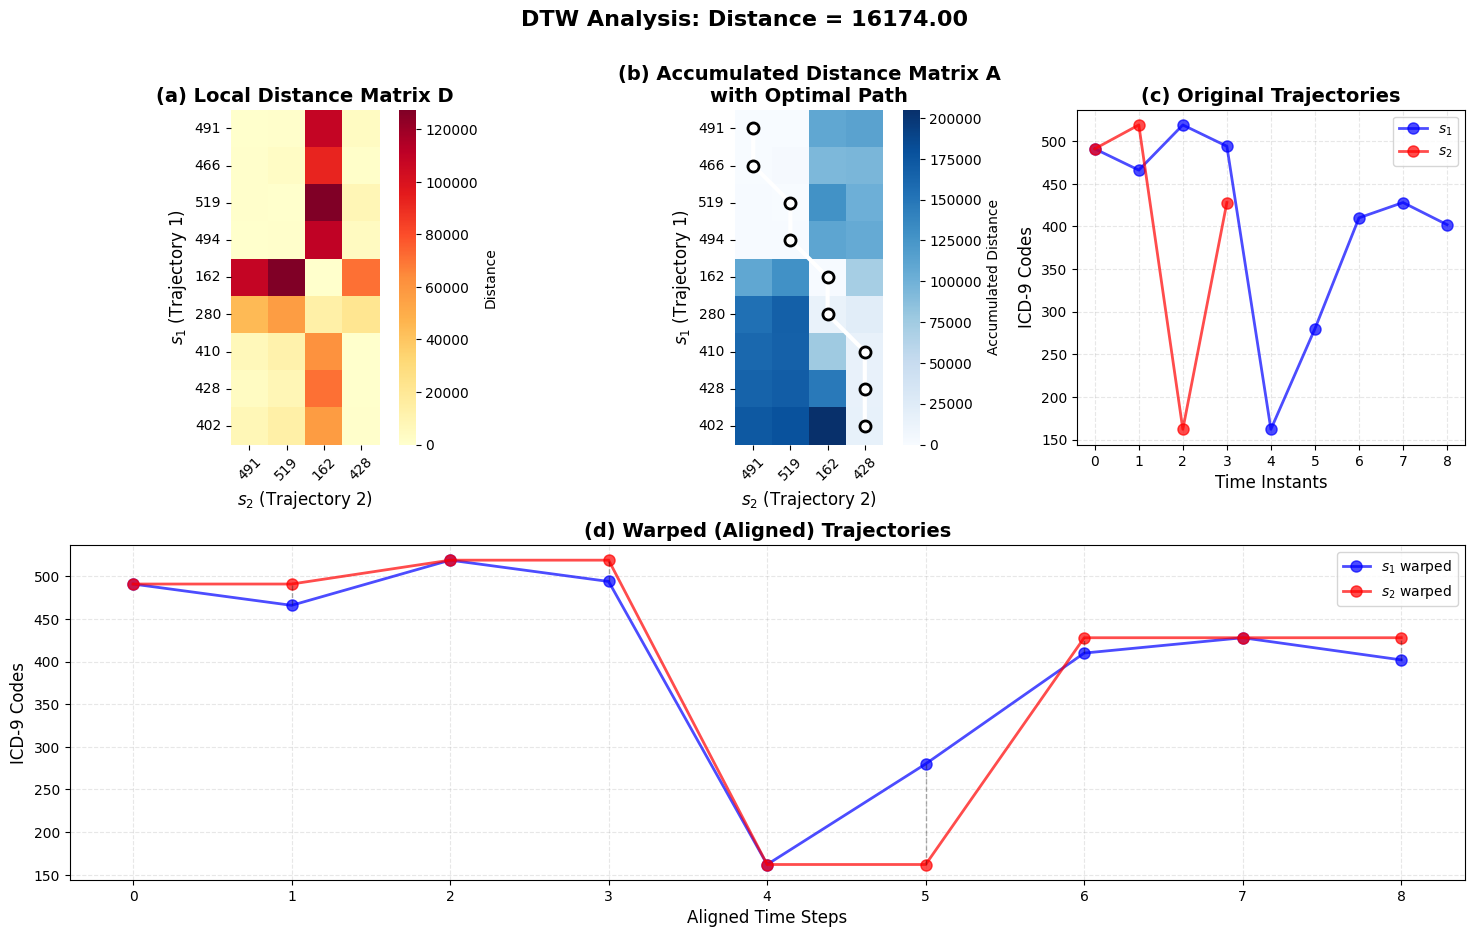


Example 2: MIMIC-III patients
Patient 36 vs Patient 107
DTW distance: 752872.00
Trajectory length: 3 vs 3
Optimal path length: 4


/var/folders/fn/_32pmlmn6zq_hpq142dgnrv00000gq/T/ipykernel_34799/2341086579.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


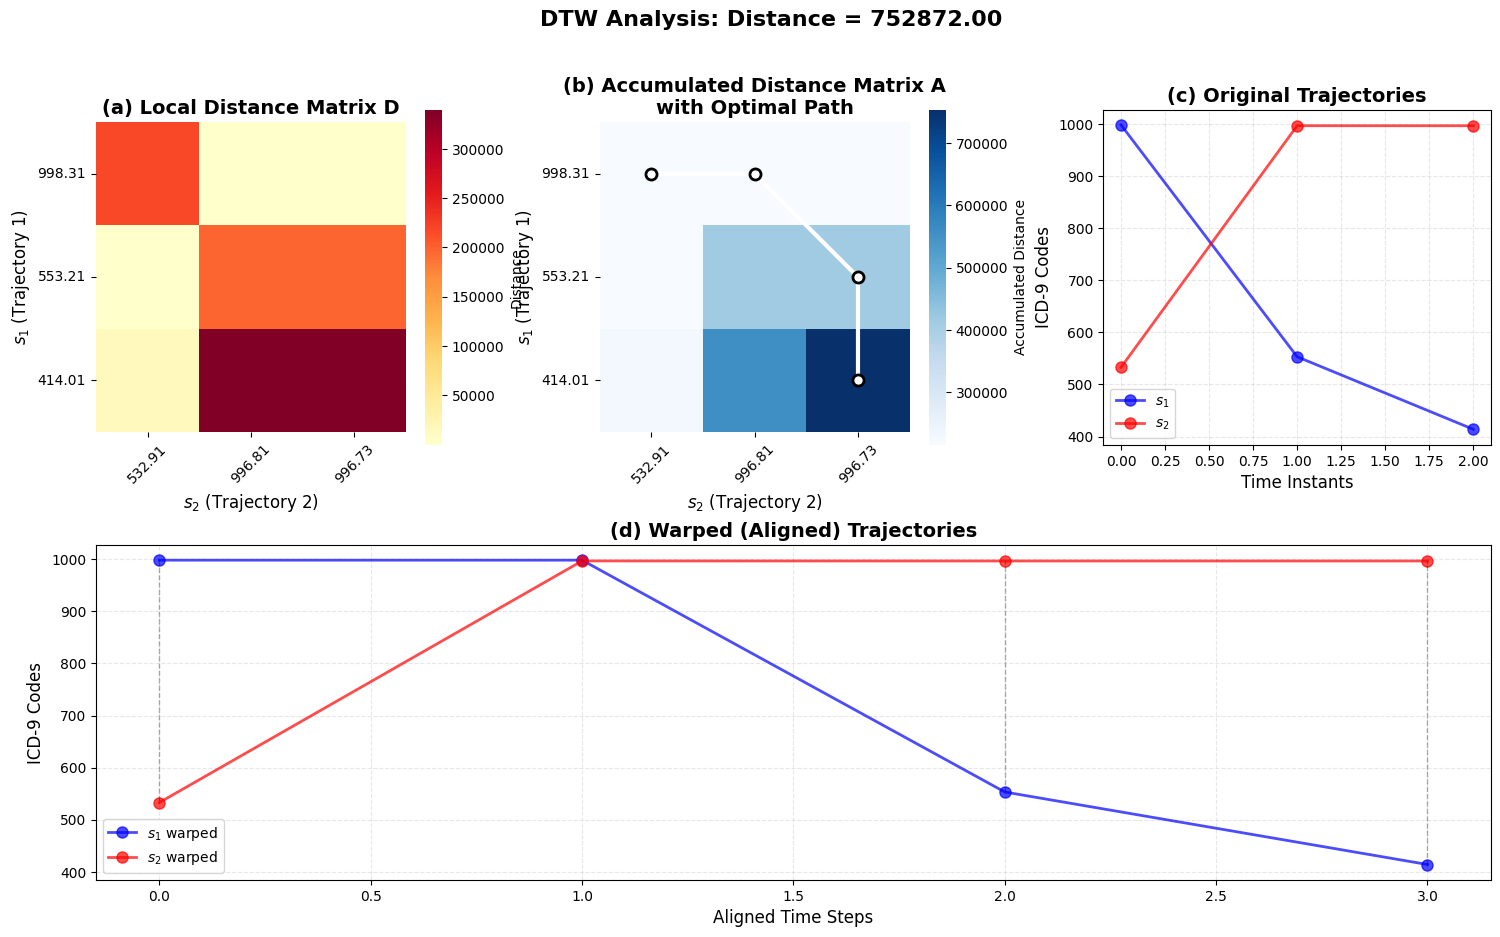


Optimal path details:
Step 0: s1[0]=998.31 <-> s2[0]=532.91
Step 1: s1[0]=998.31 <-> s2[1]=996.81
Step 2: s1[1]=553.21 <-> s2[2]=996.73
Step 3: s1[2]=414.01 <-> s2[2]=996.73


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def compute_local_distance_matrix(traj1, traj2):
    """计算局部距离矩阵"""
    s1 = np.array([float(code) for code in traj1])
    s2 = np.array([float(code) for code in traj2])
    D = (s1[:, np.newaxis] - s2[np.newaxis, :]) ** 2
    return D

def compute_accumulated_distance_matrix(D):
    """计算累积距离矩阵"""
    N, M = D.shape
    A = np.zeros((N, M))
    
    # 初始化
    A[0, 0] = D[0, 0]
    for i in range(1, N):
        A[i, 0] = A[i-1, 0] + D[i, 0]
    for j in range(1, M):
        A[0, j] = A[0, j-1] + D[0, j]
    
    # 动态规划填充
    for i in range(1, N):
        for j in range(1, M):
            A[i, j] = D[i, j] + min(A[i-1, j-1], A[i-1, j], A[i, j-1])
    
    return A

def find_optimal_path(A):
    """通过回溯找到最优路径"""
    path = []
    i, j = A.shape[0] - 1, A.shape[1] - 1
    path.append((i, j))
    
    while i > 0 or j > 0:
        if i == 0:
            j -= 1
        elif j == 0:
            i -= 1
        else:
            # 找到来自哪个方向（最小的那个）
            candidates = [
                (A[i-1, j-1], i-1, j-1),  # 对角线
                (A[i-1, j], i-1, j),      # 上
                (A[i, j-1], i, j-1)       # 左
            ]
            min_val, i, j = min(candidates, key=lambda x: x[0])
        path.append((i, j))
    
    return path[::-1]  # 反转，从起点到终点

def visualize_dtw_analysis(traj1, traj2, show_numbers=True):
    """
    DTW Visualization
    
    Args:
        traj1: 第一个轨迹
        traj2: 第二个轨迹
        show_numbers: 是否在矩阵上显示数值
    """
    # 计算矩阵
    D = compute_local_distance_matrix(traj1, traj2)
    A = compute_accumulated_distance_matrix(D)
    path = find_optimal_path(A)
    
    # 创建子图
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    # ========== (a) 局部距离矩阵 ==========
    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(D, annot=show_numbers, fmt='.0f', cmap='YlOrRd', 
                cbar_kws={'label': 'Distance'}, ax=ax1, square=True)
    ax1.set_xlabel('$s_2$ (Trajectory 2)', fontsize=12)
    ax1.set_ylabel('$s_1$ (Trajectory 1)', fontsize=12)
    ax1.set_title('(a) Local Distance Matrix D', fontsize=14, fontweight='bold')
    ax1.set_xticklabels([str(c) for c in traj2], rotation=45)
    ax1.set_yticklabels([str(c) for c in traj1], rotation=0)
    
    # ========== (b) 累积距离矩阵 + 最优路径 ==========
    ax2 = fig.add_subplot(gs[0, 1])
    sns.heatmap(A, annot=False, cmap='Blues', 
                cbar_kws={'label': 'Accumulated Distance'}, ax=ax2, square=True)
    
    # 绘制最优路径
    path_array = np.array(path)
    ax2.plot(path_array[:, 1] + 0.5, path_array[:, 0] + 0.5, 
             'w-', linewidth=3, marker='o', markersize=8, 
             markerfacecolor='white', markeredgecolor='black', markeredgewidth=2)
    
    ax2.set_xlabel('$s_2$ (Trajectory 2)', fontsize=12)
    ax2.set_ylabel('$s_1$ (Trajectory 1)', fontsize=12)
    ax2.set_title('(b) Accumulated Distance Matrix A\nwith Optimal Path', 
                  fontsize=14, fontweight='bold')
    ax2.set_xticklabels([str(c) for c in traj2], rotation=45)
    ax2.set_yticklabels([str(c) for c in traj1], rotation=0)
    
    # ========== (c) 原始轨迹 ==========
    ax3 = fig.add_subplot(gs[0, 2])
    time1 = np.arange(len(traj1))
    time2 = np.arange(len(traj2))
    
    ax3.plot(time1, [float(c) for c in traj1], 'b-o', linewidth=2, 
             markersize=8, label='$s_1$', alpha=0.7)
    ax3.plot(time2, [float(c) for c in traj2], 'r-o', linewidth=2, 
             markersize=8, label='$s_2$', alpha=0.7)
    ax3.set_xlabel('Time Instants', fontsize=12)
    ax3.set_ylabel('ICD-9 Codes', fontsize=12)
    ax3.set_title('(c) Original Trajectories', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3, linestyle='--')
    
    # ========== (d) Warped轨迹（对齐后） ==========
    ax4 = fig.add_subplot(gs[1, :])
    
    # 根据最优路径创建warped轨迹
    warped_time = np.arange(len(path))
    warped_traj1 = [float(traj1[i]) for i, j in path]
    warped_traj2 = [float(traj2[j]) for i, j in path]
    
    ax4.plot(warped_time, warped_traj1, 'b-o', linewidth=2, 
             markersize=8, label='$s_1$ warped', alpha=0.7)
    ax4.plot(warped_time, warped_traj2, 'r-o', linewidth=2, 
             markersize=8, label='$s_2$ warped', alpha=0.7)
    
    # 绘制对齐的连接线
    for t in range(len(path)):
        ax4.plot([warped_time[t], warped_time[t]], 
                [warped_traj1[t], warped_traj2[t]], 
                'k--', alpha=0.3, linewidth=1)
    
    ax4.set_xlabel('Aligned Time Steps', fontsize=12)
    ax4.set_ylabel('ICD-9 Codes', fontsize=12)
    ax4.set_title('(d) Warped (Aligned) Trajectories', fontsize=14, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3, linestyle='--')
    
    # 显示DTW距离
    dtw_distance = A[-1, -1]
    fig.suptitle(f'DTW Analysis: Distance = {dtw_distance:.2f}', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    return fig, D, A, path, dtw_distance

# ========== 使用论文中的例子 ==========
traj1_paper = ['491', '466', '519', '494', '162', '280', '410', '428', '402']
traj2_paper = ['491', '519', '162', '428']

print("Example 1: in the paper")
fig1, D1, A1, path1, dist1 = visualize_dtw_analysis(traj1_paper, traj2_paper, show_numbers=False)
print(f"DTW distance: {dist1:.2f}")
print(f"Optimal path length: {len(path1)}")
plt.show()

# ========== 使用MIMIC-III数据 ==========
print("\nExample 2: MIMIC-III patients")
patient_36 = unique_trajectories[36]
patient_107 = unique_trajectories[107]

fig2, D2, A2, path2, dist2 = visualize_dtw_analysis(patient_36, patient_107, show_numbers=False)
print(f"Patient 36 vs Patient 107")
print(f"DTW distance: {dist2:.2f}")
print(f"Trajectory length: {len(patient_36)} vs {len(patient_107)}")
print(f"Optimal path length: {len(path2)}")
plt.show()

# ========== 详细信息 ==========
print("\nOptimal path details:")
for step, (i, j) in enumerate(path2[:10]):  # 显示前10步
    print(f"Step {step}: s1[{i}]={patient_36[i]} <-> s2[{j}]={patient_107[j]}")
if len(path2) > 10:
    print(f"... (and {len(path2)-10} steps)")

In [53]:
unique_trajectories[36]

['998.31', '553.21', '414.01']

In [ ]:
def extract_common_trajectory(traj1, traj2, D=None):
    """
    从两个疾病历史向量中提取共同疾病轨迹（保持时间顺序）
    
    Args:
        traj1: list of disease codes for patient 1
        traj2: list of disease codes for patient 2
        D: local distance matrix (可选，不使用也可以)
    
    Returns:
        common_traj: list, common disease trajectory (ordered by time)
    """
    # 找出所有匹配的代码
    matches = []
    for n, code1 in enumerate(traj1):
        for m, code2 in enumerate(traj2):
            if str(code1) == str(code2): 
                matches.append((n, m, code1))   # n是traj1中的索引位置(时间点)，m是traj2中的索引，code1是匹配的代码
    
    # 如果匹配数少于2个，返回空
    if len(matches) < 2:
        return []
    
    # 按照在traj2中的顺序排序（保持时间顺序）
    matches.sort(key=lambda x: x[1])
    
    # 提取共同轨迹（确保在traj1中也是递增的）
    common_traj = []
    last_n = -1
    
    for n, m, code in matches:
        if n > last_n:  # 确保在traj1中也保持时间顺序
            common_traj.append(code)
            last_n = n
    
    return common_traj if len(common_traj) >= 2 else []

common_trajectory = extract_common_trajectory(unique_trajectories[36], unique_trajectories[107])
common_trajectory

[]

In [ ]:
def extract_all_common_trajectories(unique_trajectories, min_length=2, min_patients=2):
    """
    提取所有共同疾病轨迹
    
    Args:
        unique_trajectories: dict, 患者的唯一疾病代码序列
        min_length: int, 共同轨迹的最小长度
        min_patients: int, 共享轨迹的最小患者数
    
    Returns:
        common_trajectories: dict, key是轨迹（tuple），value是包含该轨迹的患者列表
    """
    from collections import defaultdict
    
    common_trajectories = defaultdict(list)
    patient_ids = list(unique_trajectories.keys())
    
    print(f"Comparing {len(patient_ids)} patients pairwise...")
    
    # 两两比较所有患者
    for i in range(len(patient_ids)):
        if i % 500 == 0:
            print(f"Processing patient {i}/{len(patient_ids)}...")
        
        pid1 = patient_ids[i]
        traj1 = unique_trajectories[pid1]
        
        for j in range(i + 1, len(patient_ids)):
            pid2 = patient_ids[j]
            traj2 = unique_trajectories[pid2]
            
            # 计算局部距离矩阵
            # D = compute_local_distance_matrix(traj1, traj2)
            
            # 提取共同轨迹
            common_traj = extract_common_trajectory(traj1, traj2)
            
            if len(common_traj) >= min_length:
                traj_tuple = tuple(common_traj)
                if pid1 not in common_trajectories[traj_tuple]:
                    common_trajectories[traj_tuple].append(pid1)
                if pid2 not in common_trajectories[traj_tuple]:
                    common_trajectories[traj_tuple].append(pid2)
    
    # 只保留至少被min_patients个患者共享的轨迹
    filtered_trajectories = {
        traj: patients for traj, patients in common_trajectories.items()
        if len(patients) >= min_patients
    }
    
    print(f"\nFound {len(filtered_trajectories)} common trajectories")
    
    # 按轨迹长度分组统计
    length_distribution = defaultdict(int)
    for traj in filtered_trajectories.keys():
        length_distribution[len(traj)] += 1
    
    print("\nDistribution by trajectory length:")
    for length in sorted(length_distribution.keys()):
        print(f"  Length {length}: {length_distribution[length]} trajectories")
    
    return filtered_trajectories

common_trajectories = extract_all_common_trajectories(
    unique_trajectories, 
    min_length=2,      # 最小轨迹长度
    min_patients=2     # 最小共享患者数
)
common_trajectories

In [59]:
# 查看最常见的轨迹
print("\nThe most common 20 disease trajectories (with temporal directionality):")
sorted_trajectories = sorted(
    common_trajectories.items(), 
    key=lambda x: len(x[1]), 
    reverse=True
)

for i, (traj, patients) in enumerate(sorted_trajectories[:20]):
    print(f"{i+1}. {traj} - {len(patients)} patients")


The most common 20 disease trajectories (with temporal directionality):
1. ('038.9', '518.81') - 24 patients
2. ('507.0', '038.9') - 24 patients
3. ('518.81', '486') - 23 patients
4. ('518.81', '038.9') - 22 patients
5. ('518.81', '518.84') - 22 patients
6. ('038.9', '486') - 21 patients
7. ('518.81', '491.21') - 19 patients
8. ('038.9', '996.62') - 18 patients
9. ('038.9', '507.0') - 18 patients
10. ('414.01', '410.71') - 18 patients
11. ('486', '038.9') - 18 patients
12. ('518.81', '507.0') - 18 patients
13. ('507.0', '486') - 16 patients
14. ('486', '518.81') - 16 patients
15. ('410.71', '038.9') - 15 patients
16. ('038.9', '410.71') - 15 patients
17. ('491.21', '518.81') - 14 patients
18. ('584.9', '038.9') - 13 patients
19. ('038.9', '584.9') - 13 patients
20. ('038.9', '008.45') - 12 patients
